### Task 3
#### Layyana Junaid 23k0056

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [ ]:
videos_dir = 'EchoNet-Dynamic/Videos'

video_files = os.listdir(videos_dir)
print(f"Total videos: {len(video_files)}")
print(video_files[:5])

Total videos: 10031
['0X100009310A3BD7FC.mp4', '0X1002E8FBACD08477.mp4', '0X1005D03EED19C65B.mp4', '0X10075961BC11C88E.mp4', '0X10094BA0A028EAC3.mp4']


EchoNet-Dynamic/Videos\0X100009310A3BD7FC.mp4
FPS: 50.0
Total frames: 174
Resolution: 112x112


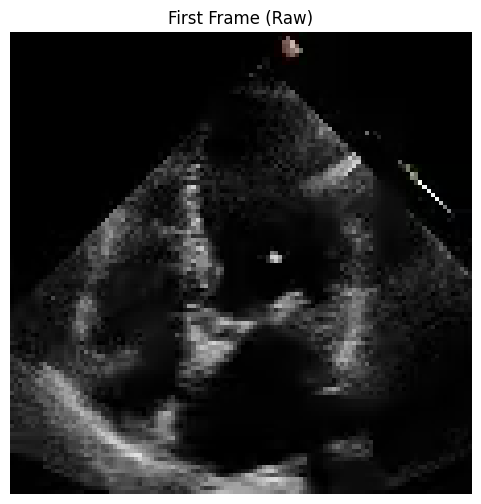

In [3]:
video_path = os.path.join(videos_dir, video_files[0])  # picks the first one
print(video_path)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")
print(f"Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
print(f"Resolution: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")

ret, frame = cap.read()
if not ret:
    raise IOError("Could not read first frame")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(frame_rgb)
plt.title('First Frame (Raw)')
plt.axis('off')
plt.show()

cap.release()

In [5]:
def gray_world_balance(img_bgr):
    img_float = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img_float)
    
    b_mean, g_mean, r_mean = b.mean(), g.mean(), r.mean()
    gray_mean = (b_mean + g_mean + r_mean) / 3
    
    b = b * (gray_mean / b_mean)
    g = g * (gray_mean / g_mean)
    r = r * (gray_mean / r_mean)
    
    balanced = cv2.merge([b, g, r])
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)
    return balanced

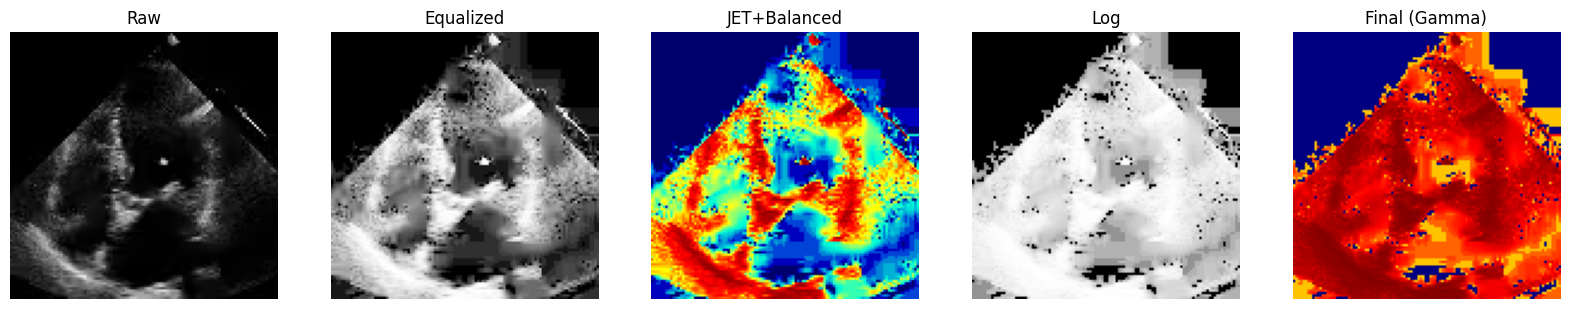

In [6]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

equalized = cv2.equalizeHist(gray)

heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

balanced = gray_world_balance(heatmap)

eq_float = equalized.astype(np.float32)
c = 255 / np.log(1 + np.max(eq_float))
log_transformed = c * np.log(1 + eq_float)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

gamma = 0.7  
norm = log_transformed.astype(np.float32) / 255.0
gamma_transformed = np.power(norm, gamma)
gamma_transformed = (gamma_transformed * 255).clip(0, 255).astype(np.uint8)

final_colored = cv2.applyColorMap(gamma_transformed, cv2.COLORMAP_JET)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
titles = ['Raw', 'Equalized', 'JET+Balanced', 'Log', 'Final (Gamma)']
imgs = [gray, equalized, cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB), log_transformed, cv2.cvtColor(final_colored, cv2.COLOR_BGR2RGB)]
cmaps = ['gray', 'gray', None, 'gray', None]

for ax, title, im, cmap in zip(axes, titles, imgs, cmaps):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.show()

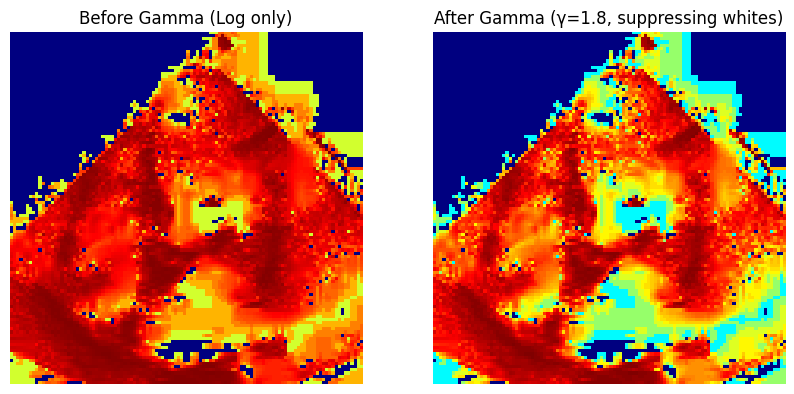

In [7]:
gamma = 1.8  # >1 pulls bright values down, suppressing backscatter whites

norm = log_transformed.astype(np.float32) / 255.0
gamma_transformed = np.power(norm, gamma)
gamma_transformed = (gamma_transformed * 255).clip(0, 255).astype(np.uint8)

final_colored = cv2.applyColorMap(gamma_transformed, cv2.COLORMAP_JET)
final_colored_rgb = cv2.cvtColor(final_colored, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(cv2.applyColorMap(log_transformed, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB))
axes[0].set_title('Before Gamma (Log only)')
axes[0].axis('off')

axes[1].imshow(final_colored_rgb)
axes[1].set_title(f'After Gamma (γ={gamma}, suppressing whites)')
axes[1].axis('off')
plt.show()

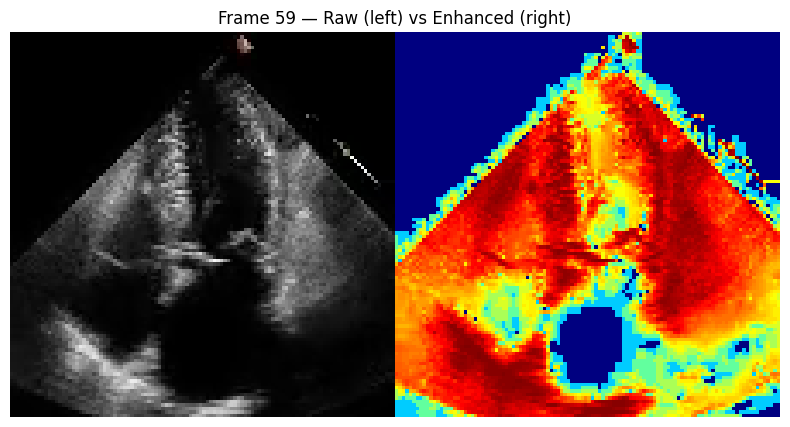

Playback finished.


In [10]:
from IPython.display import display, clear_output
import time

video_path = os.path.join(videos_dir, video_files[0])
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

def enhance_frame(frame_bgr, gamma=1.8):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
    balanced = gray_world_balance(heatmap)
    
    eq_float = equalized.astype(np.float32)
    c = 255 / np.log(1 + np.max(eq_float))
    log_t = np.clip(c * np.log(1 + eq_float), 0, 255).astype(np.uint8)
    
    norm = log_t.astype(np.float32) / 255.0
    gamma_t = np.clip(np.power(norm, gamma) * 255, 0, 255).astype(np.uint8)
    
    final = cv2.applyColorMap(gamma_t, cv2.COLORMAP_JET)
    return final

fig, ax = plt.subplots(figsize=(10, 5))

frame_count = 0
max_frames = 60  # limit for a reasonable notebook demo — full 174 works too, just slower to render

while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    
    enhanced = enhance_frame(frame, gamma=1.8)
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
    combined = np.hstack([frame_rgb, enhanced_rgb])
    
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.imshow(combined)
    plt.title(f'Frame {frame_count} — Raw (left) vs Enhanced (right)')
    plt.axis('off')
    plt.show()
    
    frame_count += 1

cap.release()
print("Playback finished.")

we need to run the cell to make it run and see the changes overtime...kinda cool damn!!